In [58]:
# %pip install scikit-learn
# %pip install nbconvert
# %jupyter nbconvert --to script test.ipynb

In [59]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

import INUVisionLib as ivl

print("\n라이브러리 로드")


라이브러리 로드


# **[시작] 카메라 호출**

In [111]:
print("리얼센스 기기 검색 중...\n" + "-"*30)

devices = ivl.get_realsense_ids()

if devices:
    print(f"총 {len(devices)}대의 카메라가 연결되어 있습니다.\n")
    for serial, name in devices.items():
        print(f"📷 모델명: {name}")
        print(f"🔑 기기 ID (Serial): {serial}\n")
else:
    print("카메라 연결 상태(USB 포트 등)를 확인해주세요.")

리얼센스 기기 검색 중...
------------------------------
총 1대의 카메라가 연결되어 있습니다.

📷 모델명: Intel RealSense D435IF
🔑 기기 ID (Serial): 327122072783



### 카메라 설정

[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.2m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (30 프레임 대기)


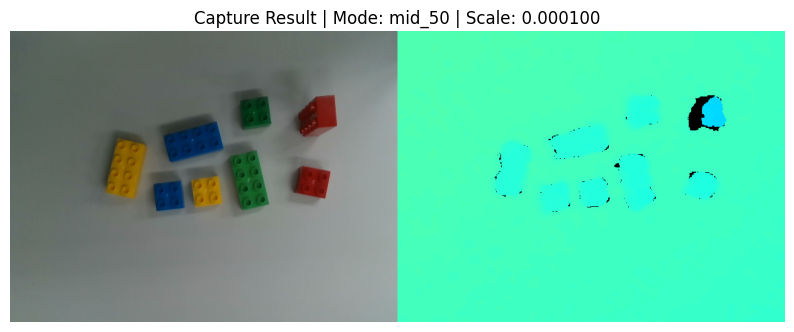

✅ 카메라 스트리밍 안전 종료 완료.


In [112]:
# 카메라 연결 확인
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0] # 첫 번째 카메라 선택

# 필요한 데이터 한 번에 추출! (시각화 켜기)
color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=True
)

# color_rgb, depth, intrinsics, scale



# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# from IPython.display import display, clear_output

# # 주피터 내 출력을 위한 matplotlib 피규어 준비
# fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# # current_mode = "macro_30"
# current_mode = "mid_50"

# print(f"[{current_mode}] 모드로 카메라를 켭니다...")

# pipeline, align, temp_filter, thres_filter = ivl.configure_realsense(
#     **ivl.CAMERA_PROFILES[current_mode]
# )

# profile_depth_units = ivl.CAMERA_PROFILES[current_mode].get("depth_Units", None)
# print("[INFO] profile depth_Units:", profile_depth_units)

# intrinsics = ivl.get_aligned_intrinsics(pipeline)
# ivl.intrinsics_checker(pipeline)

# # sensor 쪽 값도 확인만 함. downstream에는 바로 쓰지 말 것.
# depth_sensor = pipeline.get_active_profile().get_device().first_depth_sensor()
# sensor_depth_scale = depth_sensor.get_depth_scale()
# sensor_depth_units_option = depth_sensor.get_option(rs.option.depth_units)

# print("[INFO] sensor get_depth_scale():", sensor_depth_scale)
# print("[INFO] sensor option depth_units:", sensor_depth_units_option)

# print("스트리밍을 시작합니다...")

# try:
#     print("🔥 카메라 센서 안정화 및 예열 중 (초기 30프레임 버림)...")
#     for _ in range(30):
#         pipeline.wait_for_frames()
#     print("✅ 예열 완료! 본격적인 스트리밍을 시작합니다.\n")

#     last_debug_info = None

#     for i in range(2):
#         depth_img, color_img, depth_scale, debug_info = ivl.get_aligned_frames_with_units(
#             pipeline=pipeline,
#             align=align,
#             temp_filter=temp_filter,
#             thres_filter=thres_filter,
#             profile_depth_units=profile_depth_units,
#             apply_filter=True
#         )

#         if depth_img is None or color_img is None:
#             continue

#         last_debug_info = debug_info

#         # meter 기준 depth colormap
#         if current_mode == "macro_30":
#             vis_min_m = 0.08
#             vis_max_m = 0.35
#         elif current_mode == "mid_50":
#             vis_min_m = 0.15
#             vis_max_m = 0.80
#         else:
#             vis_min_m = 0.20
#             vis_max_m = 3.00

#         depth_colormap_rgb, depth_m = ivl.make_depth_colormap_meters(
#             depth_img=depth_img,
#             depth_scale=depth_scale,
#             min_m=vis_min_m,
#             max_m=vis_max_m
#         )

#         images = np.hstack((color_img, depth_colormap_rgb))

#         ax.clear()
#         ax.imshow(images)
#         ax.axis("off")

#         title = (
#             f"mode={current_mode} | "
#             f"depth_scale_used={depth_scale:.8f} | "
#             f"center_raw={debug_info['center_raw']} | "
#             f"center_raw*scale={debug_info['center_raw_times_used_scale']} | "
#             f"center_get_distance={debug_info['center_distance_m']}"
#         )
#         ax.set_title(title, fontsize=9)

#         display(fig)
#         clear_output(wait=True)

#     print("\n[LAST DEPTH DEBUG]")
#     if last_debug_info is not None:
#         for k, v in last_debug_info.items():
#             print(k, ":", v)

# except KeyboardInterrupt:
#     print("사용자에 의해 스트리밍이 강제 중지되었습니다.")

# finally:
#     pipeline.stop()
#     print("스트리밍이 안전하게 종료되었습니다.")

#     color_img_bgr = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)
#     depth_img = depth_img
#     # intrinsics

#     intrinsics = ivl.get_aligned_intrinsics(pipeline)

### 밝기 조절

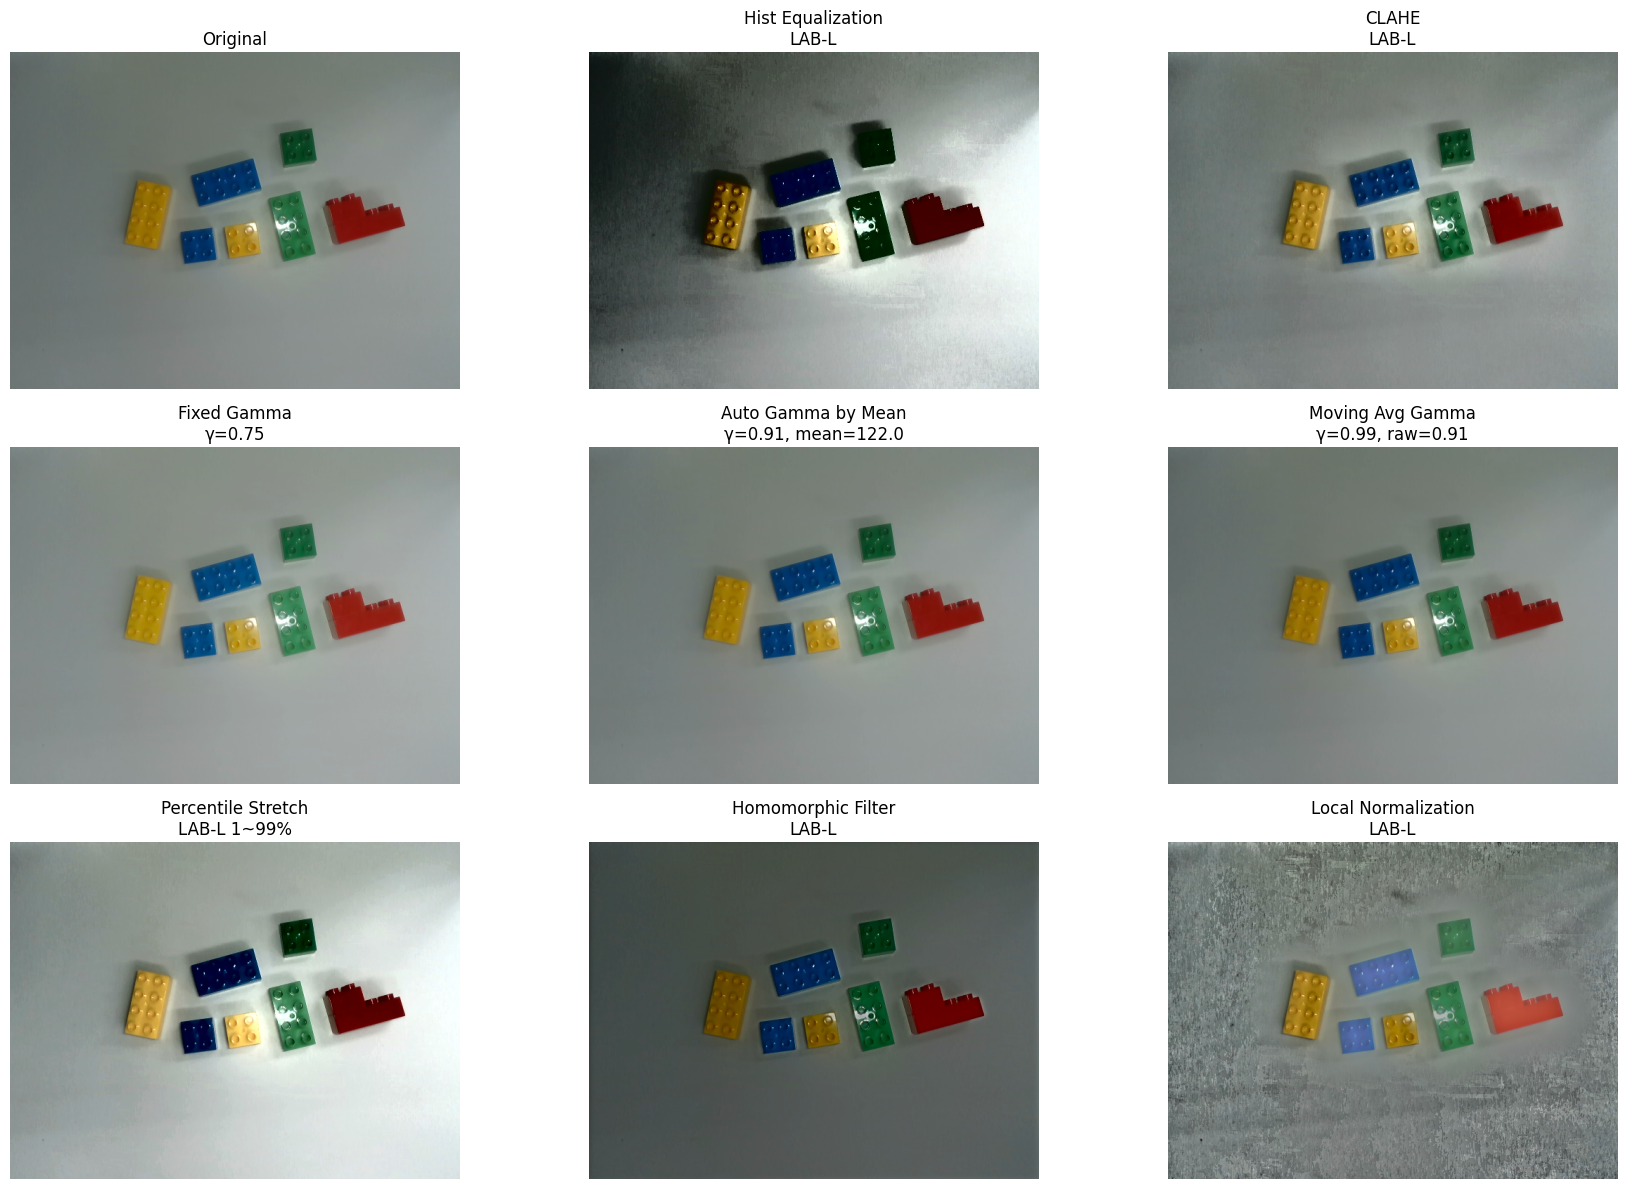

In [108]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# color_rgb : RGB 이미지, shape = (480, 640, 3) 가정
# ============================================================

color_rgb = cv2.cvtColor(color_rgb,cv2.COLOR_BGR2RGB)

# 혹시 float이면 uint8로 변환
if color_rgb.dtype != np.uint8:
    color_rgb = np.clip(color_rgb, 0, 255).astype(np.uint8)

# 혹시 크기가 다르면 640x480으로 맞춤
color_rgb_640 = cv2.resize(color_rgb, (640, 480), interpolation=cv2.INTER_AREA)


# ============================================================
# 공통 유틸
# ============================================================
def get_lab_LAB(rgb):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    return lab, L, A, B


def merge_lab_to_rgb(L, A, B):
    lab = cv2.merge([L, A, B])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def percentile_stretch_channel(ch, low=3, high=97):
    p_low, p_high = np.percentile(ch, (low, high))
    if p_high <= p_low:
        return ch.copy()

    ch_f = ch.astype(np.float32)
    out = (ch_f - p_low) / (p_high - p_low) * 255.0
    out = np.clip(out, 0, 255).astype(np.uint8)
    return out


# ============================================================
# 1. 히스토그램 평활화 - LAB L 채널
# ============================================================
def lab_hist_equalization(rgb):
    lab, L, A, B = get_lab_LAB(rgb)
    L_eq = cv2.equalizeHist(L)
    return merge_lab_to_rgb(L_eq, A, B)


# ============================================================
# 2. CLAHE - LAB L 채널
# ============================================================
def lab_clahe(rgb, clipLimit=2.0, tileGridSize=(8, 8)):
    lab, L, A, B = get_lab_LAB(rgb)

    clahe = cv2.createCLAHE(
        clipLimit=clipLimit,
        tileGridSize=tileGridSize
    )
    L_clahe = clahe.apply(L)

    return merge_lab_to_rgb(L_clahe, A, B)


# ============================================================
# 3. 고정 감마 보정
# gamma < 1.0 : 밝게
# gamma > 1.0 : 어둡게
# ============================================================
def gamma_correction(rgb, gamma=0.75):
    table = np.array([
        ((i / 255.0) ** gamma) * 255.0
        for i in range(256)
    ]).astype(np.uint8)

    return cv2.LUT(rgb, table)


# ============================================================
# 4. 평균 밝기 기반 자동 감마
# target_mean 근처로 평균 밝기를 맞추려는 방식
# ============================================================
def auto_gamma_by_mean(rgb, target_mean=130, gamma_min=0.45, gamma_max=2.2):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mean_val = np.mean(gray)

    if mean_val <= 1:
        return rgb.copy(), 1.0, mean_val

    # mean_out = 255 * (mean_in/255)^gamma 가 target이 되도록 계산
    gamma = np.log(target_mean / 255.0) / np.log(mean_val / 255.0)
    gamma = float(np.clip(gamma, gamma_min, gamma_max))

    out = gamma_correction(rgb, gamma=gamma)
    return out, gamma, mean_val


# ============================================================
# 5. Moving Average 감마
# 실시간 스트리밍에서는 감마가 프레임마다 튀면 안 되므로 EMA 적용
# 단일 이미지 테스트에서는 prev_gamma를 직접 넣어 확인
# ============================================================
class MovingAverageGamma:
    def __init__(self, init_gamma=1.0, alpha=0.15):
        self.gamma = init_gamma
        self.alpha = alpha

    def apply(self, rgb, target_mean=130, gamma_min=0.45, gamma_max=2.2):
        _, current_gamma, mean_val = auto_gamma_by_mean(
            rgb,
            target_mean=target_mean,
            gamma_min=gamma_min,
            gamma_max=gamma_max
        )

        self.gamma = (1.0 - self.alpha) * self.gamma + self.alpha * current_gamma
        out = gamma_correction(rgb, gamma=self.gamma)

        return out, self.gamma, current_gamma, mean_val


# ============================================================
# 6. Percentile Contrast Stretching - LAB L 채널
# ============================================================
def lab_percentile_stretch(rgb, low=1, high=99):
    lab, L, A, B = get_lab_LAB(rgb)
    L_stretch = percentile_stretch_channel(L, low=low, high=high)
    return merge_lab_to_rgb(L_stretch, A, B)


# ============================================================
# 7. Homomorphic Filtering - LAB L 채널
# 저주파 조명 성분을 줄이고 고주파 디테일을 살림
# ============================================================
def homomorphic_filter_L(
    rgb,
    gamma_l=0.65,
    gamma_h=1.45,
    cutoff=35,
    c=1.0
):
    lab, L, A, B = get_lab_LAB(rgb)

    L_f = L.astype(np.float32) / 255.0
    L_log = np.log1p(L_f)

    rows, cols = L.shape
    y, x = np.indices((rows, cols))
    cy, cx = rows // 2, cols // 2

    D2 = (x - cx) ** 2 + (y - cy) ** 2

    # Gaussian high-pass 형태의 homomorphic filter
    H = (gamma_h - gamma_l) * (1.0 - np.exp(-c * D2 / (cutoff ** 2))) + gamma_l

    F = np.fft.fft2(L_log)
    F_shift = np.fft.fftshift(F)

    G_shift = H * F_shift

    G = np.fft.ifftshift(G_shift)
    L_out = np.fft.ifft2(G)
    L_out = np.real(L_out)

    L_exp = np.expm1(L_out)
    L_norm = cv2.normalize(L_exp, None, 0, 255, cv2.NORM_MINMAX)
    L_norm = np.clip(L_norm, 0, 255).astype(np.uint8)

    return merge_lab_to_rgb(L_norm, A, B)


# ============================================================
# 8. 국소 정규화 - LAB L 채널
# local contrast normalization
# ============================================================
def local_normalization_L(rgb, sigma=15, eps=1e-5):
    lab, L, A, B = get_lab_LAB(rgb)

    L_f = L.astype(np.float32)

    mean = cv2.GaussianBlur(L_f, (0, 0), sigma)
    mean_sq = cv2.GaussianBlur(L_f * L_f, (0, 0), sigma)

    var = mean_sq - mean * mean
    std = np.sqrt(np.maximum(var, 0))

    norm = (L_f - mean) / (std + eps)
    norm = cv2.normalize(norm, None, 0, 255, cv2.NORM_MINMAX)
    norm = np.clip(norm, 0, 255).astype(np.uint8)

    return merge_lab_to_rgb(norm, A, B)


# ============================================================
# 실행
# ============================================================
rgb = color_rgb_640.copy()

hist_eq = lab_hist_equalization(rgb)
clahe_img = lab_clahe(rgb, clipLimit=2.0, tileGridSize=(8, 8))

gamma_fixed = gamma_correction(rgb, gamma=0.75)

auto_gamma_img, auto_gamma_used, mean_val = auto_gamma_by_mean(
    rgb,
    target_mean=130
)

ma_gamma_filter = MovingAverageGamma(init_gamma=1.0, alpha=0.15)
ma_gamma_img, ma_gamma_used, raw_gamma, mean_val2 = ma_gamma_filter.apply(
    rgb,
    target_mean=130
)

stretch_img = lab_percentile_stretch(rgb, low=1, high=99)

homomorphic_img = homomorphic_filter_L(
    rgb,
    gamma_l=0.65,
    gamma_h=1.45,
    cutoff=35,
    c=1.0
)

local_norm_img = local_normalization_L(
    rgb,
    sigma=15
)


# ============================================================
# 시각화
# ============================================================
results = [
    ("Original", rgb),
    ("Hist Equalization\nLAB-L", hist_eq),
    ("CLAHE\nLAB-L", clahe_img),
    ("Fixed Gamma\nγ=0.75", gamma_fixed),
    (f"Auto Gamma by Mean\nγ={auto_gamma_used:.2f}, mean={mean_val:.1f}", auto_gamma_img),
    (f"Moving Avg Gamma\nγ={ma_gamma_used:.2f}, raw={raw_gamma:.2f}", ma_gamma_img),
    ("Percentile Stretch\nLAB-L 1~99%", stretch_img),
    ("Homomorphic Filter\nLAB-L", homomorphic_img),
    ("Local Normalization\nLAB-L", local_norm_img),
]

plt.figure(figsize=(18, 12))

for i, (title, img) in enumerate(results, start=1):
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(title, fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

### GPT 추천 조합을 이용한 외곽선 검출

[INFO]
{'mean_val': 122.01873697916666, 'raw_gamma': 0.9140404459986281, 'ma_gamma': 0.9914040445998629}
contour count: 6


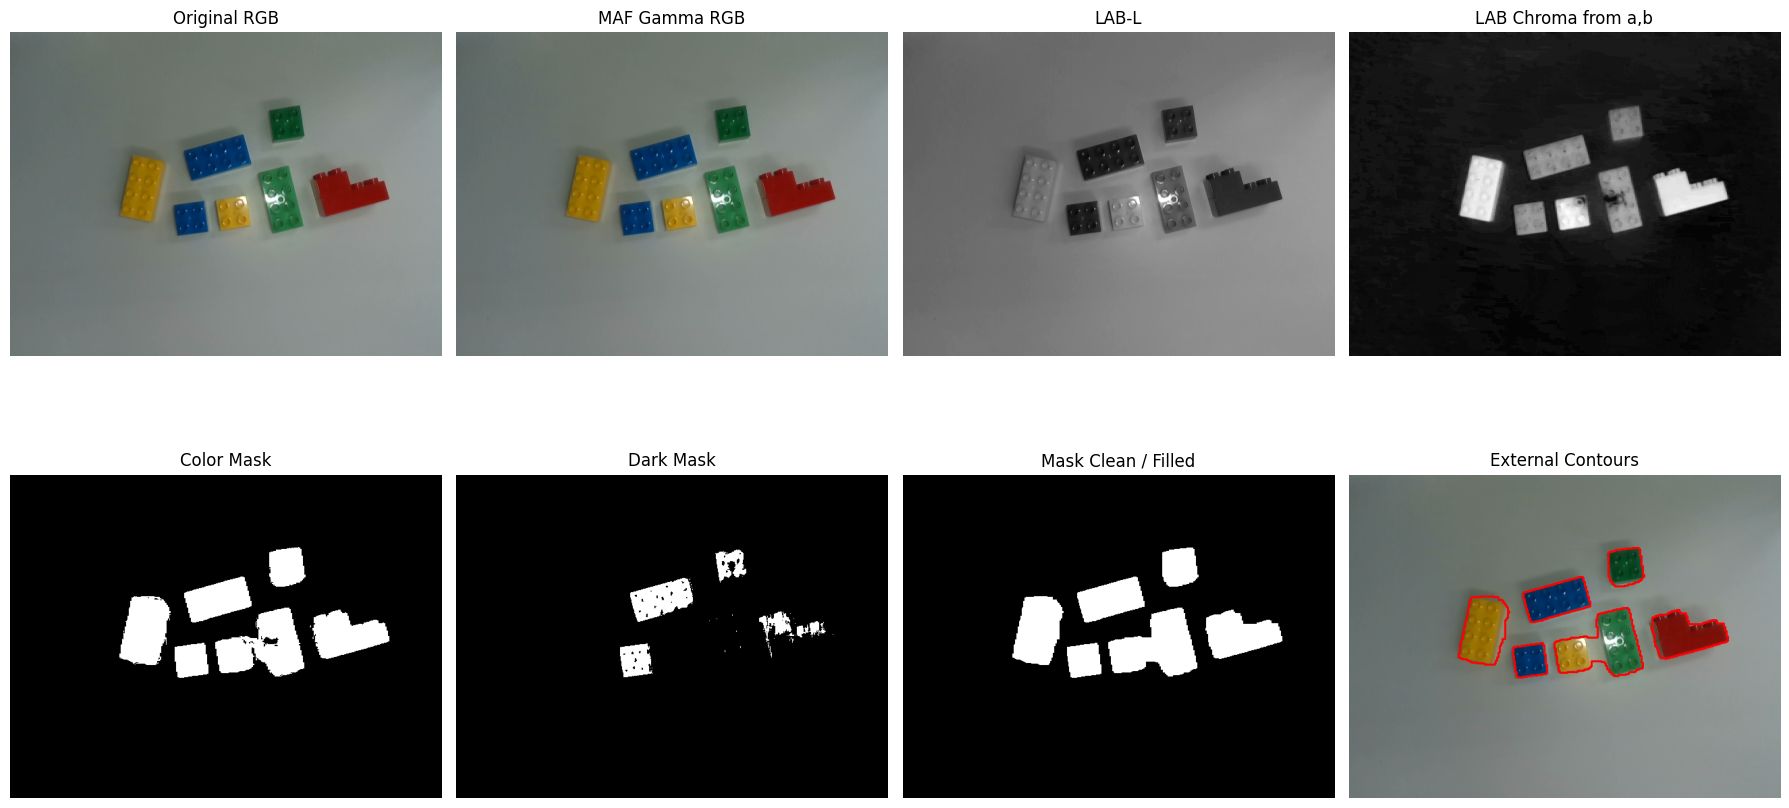

In [109]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 입력: color_rgb, RGB 이미지
# ============================================================

if color_rgb.dtype != np.uint8:
    color_rgb = np.clip(color_rgb, 0, 255).astype(np.uint8)

img_rgb = cv2.resize(color_rgb, (640, 480), interpolation=cv2.INTER_AREA)


# ============================================================
# 1. Moving Average Gamma
# ============================================================
def gamma_correction_rgb(rgb, gamma=1.0):
    table = np.array([
        ((i / 255.0) ** gamma) * 255.0
        for i in range(256)
    ]).astype(np.uint8)
    return cv2.LUT(rgb, table)


class MovingAverageGamma:
    def __init__(self, init_gamma=1.0, alpha=0.10):
        self.gamma = init_gamma
        self.alpha = alpha

    def apply(self, rgb, target_mean=130, gamma_min=0.75, gamma_max=1.30):
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        mean_val = np.mean(gray)

        if mean_val <= 1:
            raw_gamma = 1.0
        else:
            raw_gamma = np.log(target_mean / 255.0) / np.log(mean_val / 255.0)
            raw_gamma = float(np.clip(raw_gamma, gamma_min, gamma_max))

        self.gamma = (1.0 - self.alpha) * self.gamma + self.alpha * raw_gamma
        out = gamma_correction_rgb(rgb, self.gamma)

        return out, {
            "mean_val": mean_val,
            "raw_gamma": raw_gamma,
            "ma_gamma": self.gamma
        }


# ============================================================
# 2. Hole fill 함수
# ============================================================
def fill_holes(binary):
    h, w = binary.shape
    flood = binary.copy()

    mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, mask, (0, 0), 255)

    flood_inv = cv2.bitwise_not(flood)
    filled = binary | flood_inv
    return filled


# ============================================================
# 3. LAB a,b 색차 기반 foreground mask
# ============================================================
def make_lab_ab_foreground_mask(
    rgb,
    chroma_th=10,
    dark_th=65,
    use_dark=True,
    close_ksize=7,
    open_ksize=3,
    min_area=80
):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)

    # OpenCV LAB에서 회색/무채색 중심은 대략 a=128, b=128
    Af = A.astype(np.float32) - 128.0
    Bf = B.astype(np.float32) - 128.0

    chroma = np.sqrt(Af * Af + Bf * Bf)
    chroma_u8 = cv2.normalize(chroma, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 색 있는 브릭 검출
    color_mask = (chroma > chroma_th).astype(np.uint8) * 255

    # 어두운 브릭 보조 검출
    # 그림자도 어둡지만, 그림자는 chroma가 낮고 넓게 퍼져서 morphology/area에서 줄어듦
    if use_dark:
        dark_mask = (L < dark_th).astype(np.uint8) * 255
        mask = cv2.bitwise_or(color_mask, dark_mask)
    else:
        dark_mask = np.zeros_like(color_mask)
        mask = color_mask.copy()

    # 노이즈 제거
    if open_ksize >= 3:
        k_open = np.ones((open_ksize, open_ksize), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k_open, iterations=1)

    # 객체 내부 구멍/스터드 구멍 메우기
    if close_ksize >= 3:
        k_close = np.ones((close_ksize, close_ksize), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=2)

    mask = fill_holes(mask)

    # 작은 찌꺼기 제거
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            clean[labels == i] = 255

    return {
        "L": L,
        "A": A,
        "B": B,
        "chroma": chroma_u8,
        "color_mask": color_mask,
        "dark_mask": dark_mask,
        "mask_raw": mask,
        "mask_clean": clean
    }


# ============================================================
# 4. 외곽 contour 추출
# ============================================================
def extract_external_contours(mask, rgb, min_area=100):
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contours = [c for c in contours if cv2.contourArea(c) >= min_area]

    vis = rgb.copy()
    cv2.drawContours(vis, contours, -1, (255, 0, 0), 2)

    return contours, vis


# ============================================================
# 실행
# ============================================================
gamma_filter = MovingAverageGamma(init_gamma=1.0, alpha=0.10)

rgb_gamma, gamma_info = gamma_filter.apply(
    img_rgb,
    target_mean=130,
    gamma_min=0.75,
    gamma_max=1.30
)

mask_result = make_lab_ab_foreground_mask(
    rgb_gamma,
    chroma_th=10,
    dark_th=65,
    use_dark=True,
    close_ksize=7,
    open_ksize=3,
    min_area=80
)

contours, contour_vis = extract_external_contours(
    mask_result["mask_clean"],
    img_rgb,
    min_area=100
)

print("[INFO]")
print(gamma_info)
print("contour count:", len(contours))

plt.figure(figsize=(18, 10))

show_items = [
    ("Original RGB", img_rgb, "rgb"),
    ("MAF Gamma RGB", rgb_gamma, "rgb"),
    ("LAB-L", mask_result["L"], "gray"),
    ("LAB Chroma from a,b", mask_result["chroma"], "gray"),
    ("Color Mask", mask_result["color_mask"], "gray"),
    ("Dark Mask", mask_result["dark_mask"], "gray"),
    ("Mask Clean / Filled", mask_result["mask_clean"], "gray"),
    ("External Contours", contour_vis, "rgb"),
]

for i, (title, im, mode) in enumerate(show_items, start=1):
    plt.subplot(2, 4, i)
    if mode == "rgb":
        plt.imshow(im)
    else:
        plt.imshow(im, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **욜로 인지**

### **YOLO V8 세그멘테이션 기준 영역 잡기**

🎯 [SUCCESS] 8개의 타겟 객체 마스크 병합 완료


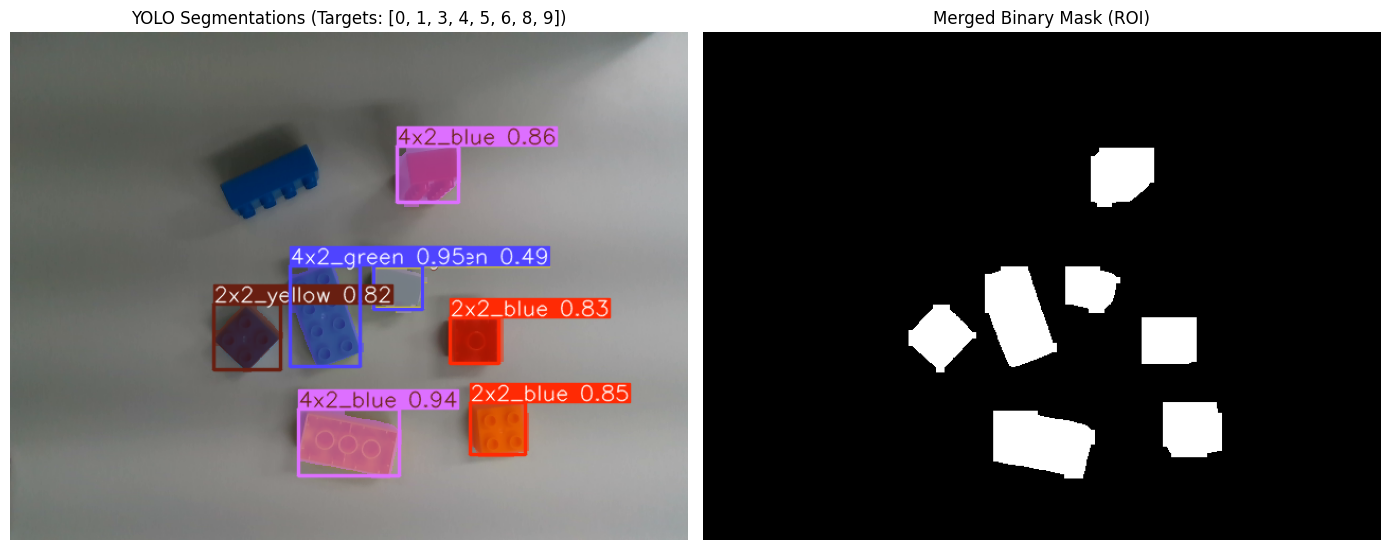

In [70]:
# color_rgb, depth, intrinsics, scale

# 1. 모델은 프로그램 시작 시 한 번만 로드하는 것이 좋습니다 (속도 최적화)
model = YOLO("yolo_models/duplo_2_low_2/weights/best.pt")
# model = YOLO("yolo_models/manip_segmentor_0528.pt")

# ... (카메라에서 color_img_rgb, depth_img 등을 받아오는 코드) ...

# 2. OpenCV용 BGR 변환 (앞선 캡처 함수에서 RGB를 리턴받았다면 다시 BGR로 줘야 YOLO가 색을 제대로 인식합니다)
color_img_bgr = cv2.cvtColor(color_rgb, cv2.COLOR_RGB2BGR)

# 3. 2와 7을 제외한 타겟 클래스 리스트
target_classes = [0, 1, 3, 4, 5, 6, 8, 9]

# 4. 함수 호출 (시각화 켜기)
results, mask_binary, vis_yolo = ivl.detect_objects_yolo(
    model=model, 
    color_img_bgr=color_img_bgr, 
    target_classes=target_classes, 
    visualize=True
)

# 5. 이후 병합된 mask_binary 변수를 PCA 계산이나 3D 변환 등에 사용!

# # YOLOv8 추론 (2번, 7번 제외)
# model = YOLO("yolo_models/manip_segmentor_0528.pt")
# # model = YOLO("yolo_models/train1_05_04/weights/best.pt")

# # ID 0~9 중 2와 7을 제외한 리스트 생성
# target_classes = [0, 1, 3, 4, 5, 6, 8, 9] 

# # 추론 시 classes 파라미터로 타겟 지정
# results = model(color_img_bgr, classes=target_classes)

# # 3. 마스크 병합 및 시각화용 이미지 생성
# mask_binary = np.zeros((480, 640), dtype=np.uint8)

# if len(results) > 0 and results[0].masks is not None:
#     masks = results[0].masks.data.cpu().numpy()
    
#     # 검출된 여러 개의 마스크를 하나의 ROI(관심 영역)로 합치기
#     for mask in masks:
#         mask_resized = cv2.resize(mask, (640, 480), interpolation=cv2.INTER_NEAREST)
#         # 기존 마스크와 새로운 마스크를 OR 연산으로 겹쳐서 누적
#         mask_binary = np.logical_or(mask_binary, mask_resized > 0.5).astype(np.uint8)
        
#     print(f"[SUCCESS] {len(masks)}개의 타겟 객체 마스크 병합 완료")
# else:
#     print("[WARN] 지정된 클래스의 객체가 검출되지 않았습니다.")

# # YOLO 내장 시각화 툴 활용 (바운딩 박스 + 라벨 + 세그멘테이션 색상)
# vis_yolo = results[0].plot()

# # --- 2D 검증 시각화 ---
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# axes[0].imshow(cv2.cvtColor(vis_yolo, cv2.COLOR_BGR2RGB))
# axes[0].set_title("YOLO Segmentations (Classes 2 & 7 Excluded)")
# axes[0].axis("off")

# axes[1].imshow(mask_binary, cmap='gray')
# axes[1].set_title("Combined Binary Mask ROI")
# axes[1].axis("off")

# plt.tight_layout()
# plt.show()

### 바운딩 박스가 겹치는 부분을 억제하는 전처리 추가

✂️ [INFO] 억제됨: '2x2_green' (면적:1785)가 '4x2_green' (면적:1785)에 99.6% 포함됨.

✅ 최종 검출된 유효 객체/군집 수: 7개
 - 🏷️ 4x2_blue (신뢰도: 0.94)
 - 🏷️ 4x2_green (신뢰도: 0.95)
 - 🏷️ 4x2_blue (신뢰도: 0.86)
 - 🏷️ 2x2_blue (신뢰도: 0.85)
 - 🏷️ 2x2_yellow (신뢰도: 0.82)
 - 🏷️ 2x2_blue (신뢰도: 0.83)
 - 🏷️ 4x2_green (신뢰도: 0.49)


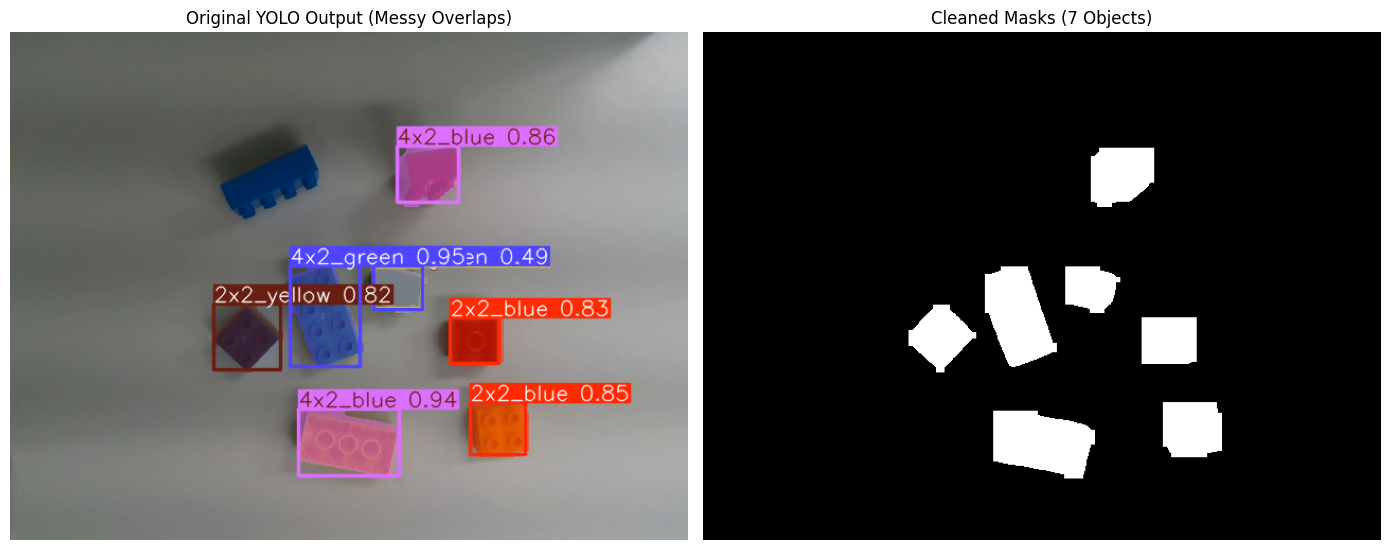

In [63]:
# # 1. 모델 추론 (이전 코드에서 작성했던 추론 부분)
# results = model(color_img_bgr, classes=[0, 1, 3, 4, 5, 6, 8, 9])

# 2. 겹치는 마스크 깔끔하게 정리 (해상도 640x480 기준, 70% 겹치면 삭제, 시각화 켬)
final_objects, clean_mask = ivl.filter_overlapping_masks(
    results=results, 
    overlap_threshold=0.70, 
    img_shape=(640, 480), 
    visualize=True
)

# 3. 이후 로직에서 clean_mask 또는 final_objects 데이터를 사용
# 예: final_objects[0]["mask"], final_objects[0]["class_name"] 등





# import numpy as np
# import cv2

# # ==========================================
# # 🎯 겹치는 마스크 병합 및 ID 정리 로직
# # ==========================================

# # 최종적으로 살아남은 객체들을 담을 리스트 (딕셔너리 형태)
# final_detected_objects = []

# if len(results) > 0 and results[0].masks is not None:
#     # 1. 필요한 데이터 추출
#     boxes = results[0].boxes
#     masks = results[0].masks.data.cpu().numpy()  # 형상: (N, H, W)
#     class_ids = boxes.cls.cpu().numpy().astype(int)
#     confidences = boxes.conf.cpu().numpy()
    
#     # YOLO 모델에 저장된 클래스 이름 딕셔너리 (예: {0: '1x2_red', 1: '2x4_red'...})
#     class_names = model.names 

#     # 2. 각 마스크의 픽셀 면적 계산
#     areas = np.array([np.sum(mask > 0.5) for mask in masks])
    
#     # 면적이 큰 순서대로 인덱스 정렬 (큰 객체가 작은 객체를 집어삼키도록 하기 위함)
#     sorted_indices = np.argsort(-areas)
    
#     suppressed_indices = set()  # 먹혀서 사라질(무시할) 작은 객체의 인덱스 모음
#     overlap_threshold = 0.70    # 포함 판단 기준: 작은 마스크의 70% 이상이 겹치면 병합

#     for i in range(len(sorted_indices)):
#         idx_large = sorted_indices[i]
        
#         # 이미 다른 큰 객체에 먹힌 객체라면 패스
#         if idx_large in suppressed_indices:
#             continue
            
#         mask_large = masks[idx_large]
#         area_large = areas[idx_large]
        
#         # 현재 (가장 큰) 객체를 최종 리스트에 추가
#         current_obj = {
#             "class_id": class_ids[idx_large],
#             "class_name": class_names[class_ids[idx_large]],
#             "confidence": confidences[idx_large],
#             "mask": cv2.resize(mask_large, (640, 480), interpolation=cv2.INTER_NEAREST) > 0.5
#         }
#         final_detected_objects.append(current_obj)
        
#         # 3. 나보다 작은 나머지 객체들과 비교
#         for j in range(i + 1, len(sorted_indices)):
#             idx_small = sorted_indices[j]
            
#             if idx_small in suppressed_indices:
#                 continue
                
#             mask_small = masks[idx_small]
#             area_small = areas[idx_small]
            
#             # 두 마스크의 교집합(AND) 계산 (둘 다 1인 픽셀 수)
#             intersection = np.sum(np.logical_and(mask_large > 0.5, mask_small > 0.5))
            
#             # 작은 마스크가 큰 마스크에 얼마나 포함되어 있는지 비율 계산
#             overlap_ratio = intersection / area_small if area_small > 0 else 0
            
#             # 만약 작은 마스크의 대부분(70% 이상)이 겹친다면 오검출로 판단하고 억제
#             if overlap_ratio > overlap_threshold:
#                 print(f"[INFO] 억제됨: '{class_names[class_ids[idx_small]]}' (면적:{area_small})가 "
#                       f"'{class_names[class_ids[idx_large]]}' (면적:{area_large})에 {overlap_ratio*100:.1f}% 포함됨.")
#                 suppressed_indices.add(idx_small)
                
#                 # 💡 옵션: 작은 마스크의 삐져나온 영역까지 큰 객체의 마스크로 완전히 합치고 싶다면 아래 주석 해제
#                 # current_obj["mask"] = np.logical_or(current_obj["mask"], cv2.resize(mask_small, (640, 480), interpolation=cv2.INTER_NEAREST) > 0.5)

# else:
#     print("[WARN] 검출된 객체가 없습니다.")


# # ==========================================
# # 📊 검증: 최종 정리된 마스크 시각화 (기존 코드 유지)
# # ==========================================
# print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_detected_objects)}개")

# final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
# for obj in final_detected_objects:
#     print(f" - Name: {obj['class_name']}")
#     final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

# # (선택) plt로 결과 확인 (기존 시각화 코드 대체)
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# axes[0].imshow(cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB))
# axes[0].set_title("Original YOLO Output (Messy Overlaps)")
# axes[0].axis("off")

# axes[1].imshow(final_combined_mask, cmap='gray')
# axes[1].set_title(f"Cleaned Masks ({len(final_detected_objects)} Objects)")
# axes[1].axis("off")

# plt.tight_layout()
# plt.show()

### 높이 기준 거름 + 가로 세로 비율 기준 거름


[INFO] RANSAC 바닥 평면 추정 시작...
✅ 바닥 평면 방정식 도출: -0.057x + 0.008y + 0.998z + 0.459 = 0

[INFO] 바닥 기준 40.0mm 이상 돌출된 포인트 추출 중...
✅ 40.0mm 이상 돌출된 3D 포인트 개수: 767개

[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...
 🔍 [비율 교정] 짧은 블록 감지 (비율:1.19). '4x2_green' -> '[C]2x2_green'


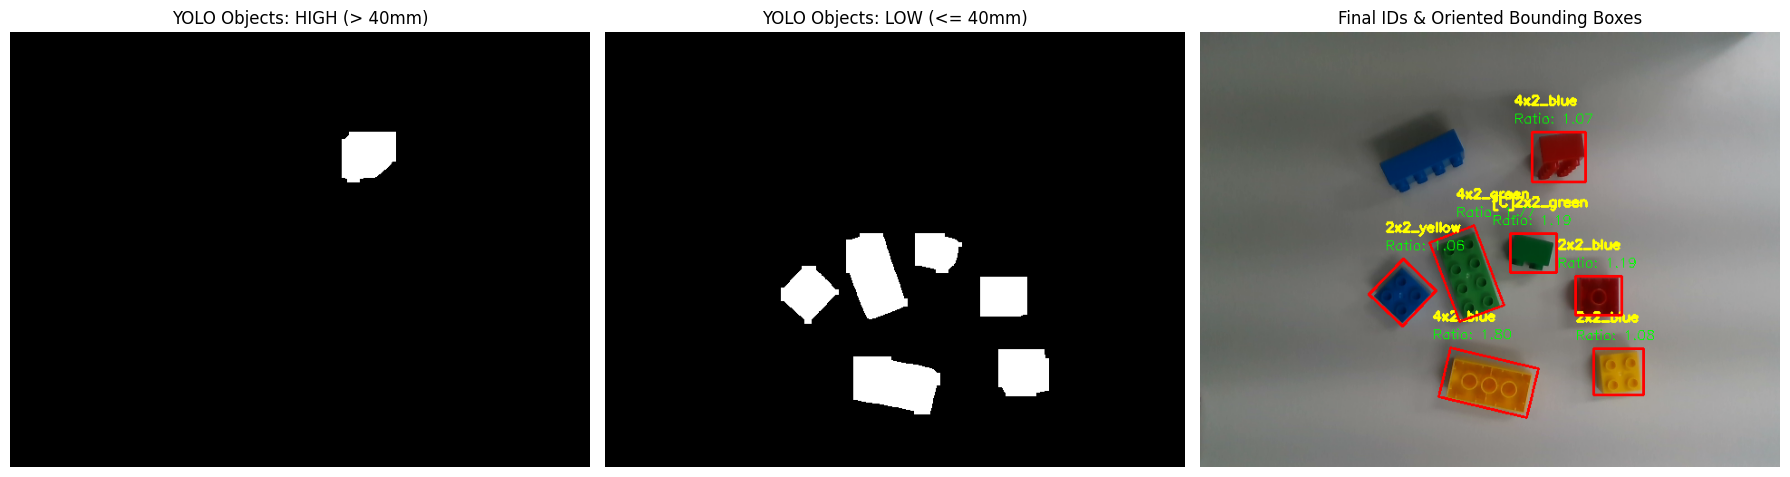

In [64]:
# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects, clean_mask



# [STEP 1] 바닥 평면 다림질
plane_model, plane_normal, filtered_depth = ivl.estimate_floor_plane(
    depth_img=depth, 
    yolo_combined_mask=clean_mask, 
    intrinsics=intrinsics, 
    depth_scale=scale, 
    depth_trunc=3.0,
    visualize=False
)


# [STEP 2] 40mm 이상 돌출 맵 추출
mask_40mm_2d = ivl.extract_high_objects_mask(
    filtered_depth_img=filtered_depth, 
    plane_normal=plane_normal, 
    d=plane_model[3], 
    intrinsics=intrinsics, 
    depth_scale=scale, 
    color_img_shape=color_rgb.shape, 
    height_threshold=0.040, 
    visualize=False
)

# [STEP 3] 최종 OBB 기반 ID 판독 및 교정
final_objects, result_vis_img = ivl.correct_object_ids(
    detected_objects=final_objects, 
    mask_high_2d=mask_40mm_2d, 
    color_img_bgr=color_rgb, 
    ratio_threshold=1.5, 
    overlap_threshold=0.20, 
    visualize=True  
)
    






# import cv2
# import numpy as np
# import open3d as o3d
# import matplotlib.pyplot as plt

# # =================================================================
# # 1. 2D Depth Map 전처리 및 배경(바닥) 전용 Depth 추출
# # =================================================================
# print("\n[STEP 1] YOLOv8 마스크를 제외한 바닥(Background) 영역 추출 중...")

# # 노이즈를 줄이기 위해 Median 블러 적용
# filtered_depth_img = cv2.medianBlur(depth_img, 5)

# # YOLOv8에서 중복 억제 후 최종 병합된 마스크(final_combined_mask) 사용
# # 객체 주변의 여유 공간까지 확실히 날리기 위해 팽창(Dilate) 적용
# kernel = np.ones((7, 7), np.uint8)
# expanded_yolo_mask = cv2.dilate(final_combined_mask, kernel, iterations=3)

# # 객체가 있는 영역의 Depth를 0으로 지워서 '순수한 바닥' 데이터만 남김
# bg_depth_img = filtered_depth_img.copy()
# bg_depth_img[expanded_yolo_mask > 0] = 0

# # =================================================================
# # 2. Open3D RANSAC 바닥 검출 및 다림질 (Flattening)
# # =================================================================
# print("\n[STEP 2] Open3D RANSAC 바닥 검출 및 평면 다림질 시작...")

# # Open3D 카메라 파라미터 세팅
# o3d_intr = o3d.camera.PinholeCameraIntrinsic(
#     int(intrinsics.width), int(intrinsics.height),
#     float(intrinsics.fx), float(intrinsics.fy),
#     float(intrinsics.ppx), float(intrinsics.ppy)
# )
# o3d_depth_scale = 1.0 / float(depth_scale)

# # 바닥 전용 포인트 클라우드 생성
# bg_depth_o3d = o3d.geometry.Image(bg_depth_img)
# bg_pcd = o3d.geometry.PointCloud.create_from_depth_image(
#     bg_depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=1.5
# )
# bg_pcd = bg_pcd.voxel_down_sample(voxel_size=0.003)

# # 아웃라이어 제거
# bg_pcd, _ = bg_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# # RANSAC 평면 검출
# plane_model, inliers = bg_pcd.segment_plane(distance_threshold=0.015, ransac_n=3, num_iterations=1000)
# a, b, c, d = plane_model
# plane_normal = np.array([a, b, c])

# # 카메라 시점 방향 보정
# if c > 0: 
#     plane_normal = -plane_normal
#     d = -d

# print(f"✅ 바닥 평면 방정식 도출: {a:.3f}x + {b:.3f}y + {c:.3f}z + {d:.3f} = 0")

# # =================================================================
# # 3. 전체 씬(Full Scene)에서 바닥 기준 40mm(0.04m) 이상인 포인트 추출
# # =================================================================
# print("\n[STEP 3] 바닥 기준 40mm(0.04m) 이상 돌출된 포인트 추출 중...")

# # 객체를 포함한 원본 전체 Depth로 Point Cloud 다시 생성
# depth_o3d = o3d.geometry.Image(filtered_depth_img)
# full_pcd = o3d.geometry.PointCloud.create_from_depth_image(
#     depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=1.5
# )
# full_pcd = full_pcd.voxel_down_sample(voxel_size=0.001)

# # 평면 방정식을 이용해 바닥으로부터의 수직 높이(signed distance) 계산
# points = np.asarray(full_pcd.points)
# signed_height = np.dot(points, plane_normal) + d

# # 🎯 핵심: 높이 임계값 40mm (0.04m) 이상인 점들만 마스킹
# height_threshold = 0.040
# above_40mm_indices = np.where(signed_height > height_threshold)[0]
# pcd_above_40mm = full_pcd.select_by_index(above_40mm_indices)

# print(f"✅ 40mm 이상 돌출된 3D 포인트 개수: {len(pcd_above_40mm.points)}개")

# # =================================================================
# # 4. 3D 포인트를 다시 2D 마스크로 사영 (Projection)
# # =================================================================
# def get_projected_mask(pcd_above, intrinsics, img_shape):
#     h, w = img_shape[:2]
#     projected_mask = np.zeros((h, w), dtype=np.uint8)
#     obj_points = np.asarray(pcd_above.points)
    
#     if len(obj_points) == 0:
#         return projected_mask
        
#     x_3d, y_3d, z_3d = obj_points[:, 0], obj_points[:, 1], obj_points[:, 2]
#     z_3d = np.where(z_3d == 0, 0.00001, z_3d)
    
#     u_coords = np.round((x_3d * intrinsics.fx / z_3d) + intrinsics.ppx).astype(int)
#     v_coords = np.round((y_3d * intrinsics.fy / z_3d) + intrinsics.ppy).astype(int)
    
#     valid = (u_coords >= 0) & (u_coords < w) & (v_coords >= 0) & (v_coords < h)
#     projected_mask[v_coords[valid], u_coords[valid]] = 1
    
#     # 미세한 구멍 메우기
#     kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
#     projected_mask = cv2.morphologyEx(projected_mask, cv2.MORPH_CLOSE, kernel)
#     return projected_mask

# # 40mm 이상 객체들의 2D 위치 맵 획득
# mask_40mm_2d = get_projected_mask(pcd_above_40mm, intrinsics, color_img_bgr.shape)

# # =================================================================
# # 5. YOLOv8 객체들과 40mm 2D 마스크 교집합 비교 및 ID(클래스명) 변경
# # =================================================================
# print("\n[STEP 4] YOLOv8 검출 영역과 40mm 이상 높이 맵 교집합 검사 및 ID 업데이트...")

# # =================================================================
# # 5. OBB 추출, 3D 높이 & OBB 비율 기반 ID 교정
# # =================================================================
# print("\n[STEP 5] 마스크 기반 OBB 추출 및 다중 조건 ID 교정 중...")

# vis_image = color_img_bgr.copy()
# N = 1.5  # 가로세로 비율 임계값

# # 분리된 결과를 시각화하기 위한 빈 캔버스(마스크) 준비
# h, w = color_img_bgr.shape[:2]
# mask_high_vis = np.zeros((h, w), dtype=np.uint8)  # 높이 > 40mm 객체들
# mask_low_vis = np.zeros((h, w), dtype=np.uint8)   # 높이 <= 40mm 객체들

# for obj in final_detected_objects:
#     yolo_mask = obj["mask"].astype(np.uint8)
#     contours, _ = cv2.findContours(yolo_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
#     if not contours:
#         continue
        
#     largest_contour = max(contours, key=cv2.contourArea)
#     rect = cv2.minAreaRect(largest_contour)
    
#     # 1. OBB 기반 물리적 가로/세로 비율 계산
#     rect_w, rect_h = rect[1]
#     ratio = max(rect_w, rect_h) / min(rect_w, rect_h) if min(rect_w, rect_h) > 0 else 0
    
#     # 2. 40mm 돌출 맵과의 교집합 연산 (높이 판별)
#     overlap = np.logical_and(yolo_mask, mask_40mm_2d)
#     overlap_ratio = np.count_nonzero(overlap) / np.count_nonzero(yolo_mask)
    
#     old_name = obj["class_name"]
    
#     # 3. 높이 및 비율에 따른 분기 처리
#     if overlap_ratio > 0.20:
#         # [A] 높이가 높은 객체 (Stacked / 돌출됨)
#         mask_high_vis = np.logical_or(mask_high_vis, yolo_mask).astype(np.uint8)
        
#         # ID가 2x2라면 4x2로 교정하고 [C] 태그 부착
#         if "2x2" in old_name:
#             new_name = old_name.replace("2x2", "4x2")
#             obj["class_name"] = f"[C]{new_name}"
#             print(f" ⚠️ [높이 교정] 쌓인 블록 감지! '{old_name}' -> '{obj['class_name']}'")
            
#     else:
#         # [B] 높이가 낮은 객체 (바닥에 있는 단일 블록)
#         mask_low_vis = np.logical_or(mask_low_vis, yolo_mask).astype(np.uint8)
        
#         # ID가 4x2 (또는 2x4)인데, OBB 비율이 N(2.0) 이하라면 2x2로 교정하고 [C] 태그 부착
#         if "4x2" in old_name or "2x4" in old_name:
#             if ratio <= N:
#                 new_name = old_name.replace("4x2", "2x2").replace("2x4", "2x2")
#                 obj["class_name"] = f"[C]{new_name}"
#                 print(f" 🔍 [비율 교정] 짧은 블록 감지 (비율:{ratio:.2f}). '{old_name}' -> '{obj['class_name']}'")

#     # 4. 시각화 렌더링 (OBB 박스 및 텍스트)
#     box = cv2.boxPoints(rect)
#     box = np.intp(box)
#     cv2.drawContours(vis_image, [box], 0, (0, 0, 255), 2)
    
#     top_point = box[np.argmin(box[:, 1])]
    
#     label_name = f"{obj['class_name']}"
#     label_ratio = f"Ratio: {ratio:.2f} ({max(rect_w, rect_h):.0f}x{min(rect_w, rect_h):.0f})"
    
#     # ID 표기 (노란색)
#     cv2.putText(vis_image, label_name, (top_point[0] - 20, top_point[1] - 30), 
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
#     # 비율 표기 (초록색)
#     cv2.putText(vis_image, label_ratio, (top_point[0] - 20, top_point[1] - 10), 
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# # =================================================================
# # 6. 최종 분할 마스크 및 결과 시각화
# # =================================================================
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# # 1. 40mm 이상 돌출된 영역과 겹치는 YOLO 객체 마스크
# axes[0].imshow(mask_high_vis, cmap="gray")
# axes[0].set_title("YOLO Objects: HIGH (> 40mm)")
# axes[0].axis("off")

# # 2. 바닥 평면(40mm 이하)에 위치한 YOLO 객체 마스크
# axes[1].imshow(mask_low_vis, cmap="gray")
# axes[1].set_title("YOLO Objects: LOW (<= 40mm)")
# axes[1].axis("off")

# # 3. 최종 교정된 ID와 OBB가 적용된 컬러 맵
# vis_image_rgb = cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB)
# axes[2].imshow(vis_image_rgb)
# axes[2].set_title("Final IDs & Oriented Bounding Boxes")
# axes[2].axis("off")

# plt.tight_layout()
# plt.show()

### Ransac 바닥 검출


[INFO] 3D 기반 돌출 객체 추출 및 2D 마스킹 파이프라인 시작...
✅ 바닥 평면 도출 성공: -0.057x + 0.008y + 0.998z + 0.459 = 0
✅ 40.0mm 이상 돌출된 객체 포인트: 111개

[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...


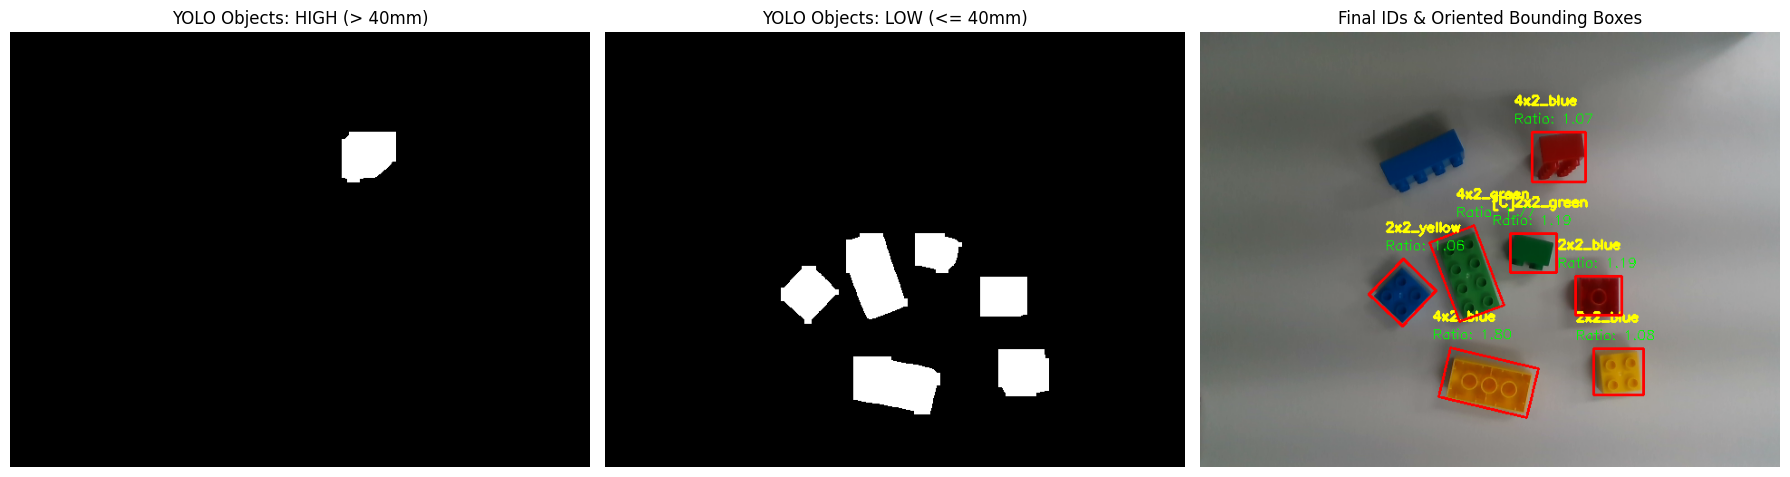

In [65]:
# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects, clean_mask

# =================================================================
# [STEP 1 & 2 통합] DBSCAN+RANSAC 바닥 추정 및 40mm 돌출 맵 사영
# =================================================================
# 기존의 바닥 다림질과 돌출 맵 추출 과정이 하나의 함수로 처리됩니다.
# 반환된 closed_mask가 곧 40mm 이상 돌출된 객체의 2D 마스크(mask_40mm_2d)입니다.
mask_40mm_2d, refined_color, contours, plane_model = ivl.extract_3d_protruding_objects(
    depth_img=depth, 
    color_img_bgr=color_rgb, 
    intrinsics=intrinsics, 
    depth_scale=scale, 
    yolo_combined_mask=clean_mask,
    depth_trunc=3.0,
    height_threshold=0.040,         # 40mm 이상 돌출 
    visualize=False  
)

# =================================================================
# [STEP 3] 최종 OBB 기반 ID 판독 및 교정
# =================================================================
# 3D 마스크 추출에 성공했을 때만 YOLO 객체(final_objects)의 ID 교정을 진행합니다.
if mask_40mm_2d is not None:
    final_objects, result_vis_img = ivl.correct_object_ids(
        detected_objects=final_objects, 
        mask_high_2d=mask_40mm_2d, 
        color_img_bgr=color_rgb, 
        ratio_threshold=1.5, 
        overlap_threshold=0.20, 
        visualize=True   
    )
else:
    print("⚠️ 바닥 검출 또는 3D 뎁스 마스크 추출 실패로 인해 ID 교정 단계를 건너뜁니다.")






# import cv2
# import numpy as np
# import open3d as o3d
# import matplotlib.pyplot as plt

# # =================================================================
# # 1. 2D Depth Map 전처리: Median Filter
# # =================================================================
# print("\n[STEP 1] Depth Map 전처리 시작...")
# filtered_depth_img = cv2.medianBlur(depth_img, 5)

# # =================================================================
# # 2. Open3D Intrinsic 및 Scale 설정
# # =================================================================
# o3d_intr = o3d.camera.PinholeCameraIntrinsic(
#     int(intrinsics.width), int(intrinsics.height),
#     float(intrinsics.fx), float(intrinsics.fy),
#     float(intrinsics.ppx), float(intrinsics.ppy)
# )
# o3d_depth_scale = 1.0 / float(depth_scale)

# # =================================================================
# # 3. 포인트 클라우드 생성 및 다운샘플링 (Single Track)
# # =================================================================
# print("\n[STEP 2] Point Cloud 생성 및 다운샘플링 (Voxel: 3mm)...")
# depth_o3d = o3d.geometry.Image(filtered_depth_img)
# full_pcd = o3d.geometry.PointCloud.create_from_depth_image(
#     depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=1.5
# )

# # 전체 씬 포인트 클라우드 (다운샘플링 적용)
# pcd = full_pcd.voxel_down_sample(voxel_size=0.003) 

# # =================================================================
# # 4. 아웃라이어 제거 (Statistical & Radius)
# # =================================================================
# print("[STEP 3] 노이즈 아웃라이어 제거 중...")
# pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
# pcd, _ = pcd.remove_radius_outlier(nb_points=10, radius=0.01)

# # =================================================================
# # 5. [수정됨] 바닥면 검출을 위한 타겟 분리 (DBSCAN + RANSAC)
# # =================================================================
# print("\n[STEP 4] DBSCAN으로 바닥 영역만 타겟팅 후 RANSAC 평면 도출...")
# labels = np.array(pcd.cluster_dbscan(eps=0.02, min_points=20, print_progress=False))

# # 바닥 방정식 초기화
# a, b, c, d = 0, 0, 1, 0  

# if len(labels) > 0 and labels.max() >= 0:
#     # 💡 핵심: 원본 pcd는 그대로 두고, 바닥을 찾을 용도의 pcd만 임시로 분리합니다.
#     largest_cluster_idx = np.argmax(np.bincount(labels[labels >= 0]))
#     main_cluster_indices = np.where(labels == largest_cluster_idx)[0]
    
#     floor_candidate_pcd = pcd.select_by_index(main_cluster_indices)
    
#     # 임시 분리된 바닥 후보에서 RANSAC 실행
#     plane_model, inliers = floor_candidate_pcd.segment_plane(distance_threshold=0.015, ransac_n=3, num_iterations=1000)
#     a, b, c, d = plane_model
#     plane_normal = np.array([a, b, c])

#     # 카메라 시점 방향 보정 (Z축이 양수가 되도록)
#     if c > 0: 
#         plane_normal = -plane_normal
#         d = -d

# print(f" -> 바닥 평면 방정식 도출: {a:.3f}x + {b:.3f}y + {c:.3f}z + {d:.3f} = 0")

# # =================================================================
# # 6. 바닥 기준 돌출된(양수 뎁스) 객체 포인트 추출
# # =================================================================
# print("\n[STEP 5] 평면 기준 5mm(0.005m) 이상 튀어나온 객체 추출...")
# points = np.asarray(pcd.points)

# # 평면 방정식 기반 Signed Height 계산 (전체 pcd 대상)
# signed_height = np.dot(points, plane_normal) + d

# # 💡 바닥(0)보다 5mm 이상 위로 솟아오른 점들만 추출
# object_indices = np.where(signed_height > 0.005)[0]
# object_pcd = pcd.select_by_index(object_indices)
# object_points = np.asarray(object_pcd.points)

# print(f" -> {len(object_points)}개의 돌출된 3D 객체 포인트 확보 완료.")

# # =================================================================
# # 7. 객체 포인트를 2D 활성화 마스크로 사영 (Projection)
# # =================================================================
# print("\n[STEP 6] 3D 돌출 객체를 2D 컬러 맵에 맞게 사영 및 마스킹 중...")
# h, w = color_img_bgr.shape[:2]
# object_mask_2d = np.zeros((h, w), dtype=np.uint8)

# if len(object_points) > 0:
#     fx, fy = intrinsics.fx, intrinsics.fy
#     cx, cy = intrinsics.ppx, intrinsics.ppy

#     x_3d, y_3d = object_points[:, 0], object_points[:, 1]
#     z_3d = np.where(object_points[:, 2] == 0, 0.00001, object_points[:, 2])

#     u_coords = np.round((x_3d * fx / z_3d) + cx).astype(int)
#     v_coords = np.round((y_3d * fy / z_3d) + cy).astype(int)

#     valid = (u_coords >= 0) & (u_coords < w) & (v_coords >= 0) & (v_coords < h)
#     object_mask_2d[v_coords[valid], u_coords[valid]] = 1

# # 3mm 다운샘플링으로 인한 구멍(Hole)을 강하게 메워줍니다.
# kernel_fill = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
# object_mask_filled = cv2.dilate(object_mask_2d, kernel_fill, iterations=1)
# object_mask_filled = cv2.morphologyEx(object_mask_filled, cv2.MORPH_CLOSE, kernel_fill)

# # =================================================================
# # 8. 컬러 이미지 컷오프 (마스킹 적용)
# # =================================================================
# # 마스크가 1인 곳(객체)만 원본 컬러 이미지 픽셀을 남기고 나머지는 검은색 처리
# cut_color_img = cv2.bitwise_and(color_img_bgr, color_img_bgr, mask=object_mask_filled)
# # =================================================================
# # 10. 마스크 후처리 (모폴로지 연산으로 구멍/잔상 제거 및 윤곽선 추출)
# # =================================================================
# print("\n[STEP 7] AND 연산을 생략하고 기존 3D 돌출 마스크를 모폴로지 연산으로 정제합니다...")

# # OpenCV 처리를 위해 0과 1로 된 마스크를 0과 255 스케일로 변환
# mask_255 = (object_mask_filled * 255).astype(np.uint8)

# # 1. 7x7 커널로 닫힘(Close) 연산: 마스크 내부의 까만 점(구멍)이나 끊어진 부분을 메워줍니다.
# kernel = np.ones((7, 7), np.uint8)
# closed_mask = cv2.morphologyEx(mask_255, cv2.MORPH_CLOSE, kernel)

# # 💡 (선택) 만약 마스크 '바깥쪽'에 하얀색 잔상 노이즈(작은 점)가 떠다닌다면 
# # 아래 주석을 해제하여 열림(Open) 연산을 추가로 적용하세요. (테두리를 깔끔하게 깎아냅니다)
# # closed_mask = cv2.morphologyEx(closed_mask, cv2.MORPH_OPEN, kernel)

# # 2. 마스크 내의 모든 윤곽선(Contours) 찾기
# contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# print(f" -> 추출된 외곽선(객체 덩어리) 개수: {len(contours)}개")

# # 3. 정제된 마스크를 기반으로 원본 컬러 이미지 컷오프
# # closed_mask는 이미 0과 255로 이루어져 있으므로 mask 파라미터로 바로 사용 가능합니다.
# refined_color_img = cv2.bitwise_and(color_img_bgr, color_img_bgr, mask=closed_mask)

# # =================================================================
# # 11. 최종 정제된 결과 시각화
# # =================================================================
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# # 1. 기존 RANSAC 마스크 (정제 전)
# axes[0].imshow(object_mask_filled, cmap="gray")
# axes[0].set_title("1. Original Protruding Mask")
# axes[0].axis("off")

# # 2. 모폴로지 연산이 적용된 마스크 (정제 후)
# axes[1].imshow(closed_mask, cmap="gray")
# axes[1].set_title("2. Morphological Closed Mask")
# axes[1].axis("off")

# # 3. 최종 컬러 컷오프 이미지
# # 외곽선을 눈으로 확인하기 위해 이미지 위에 초록색으로 Contours를 그립니다.
# vis_refined_color = refined_color_img.copy()
# cv2.drawContours(vis_refined_color, contours, -1, (0, 255, 0), 2)

# axes[2].imshow(cv2.cvtColor(vis_refined_color, cv2.COLOR_BGR2RGB))
# axes[2].set_title("3. Refined Color Objects with Contours")
# axes[2].axis("off")

# plt.tight_layout()
# plt.show()

## convex hull 적용


[INFO] 3D 기반 돌출 객체 추출 및 2D 마스킹 파이프라인 시작...
✅ 바닥 평면 도출 성공: -0.057x + 0.008y + 0.998z + 0.459 = 0
✅ 40.0mm 이상 돌출된 객체 포인트: 111개

[INFO] 조각난 2D 마스크를 Convex Hull을 이용해 복원합니다...
[SUCCESS] 2D 객체 마스크 복원 완료!


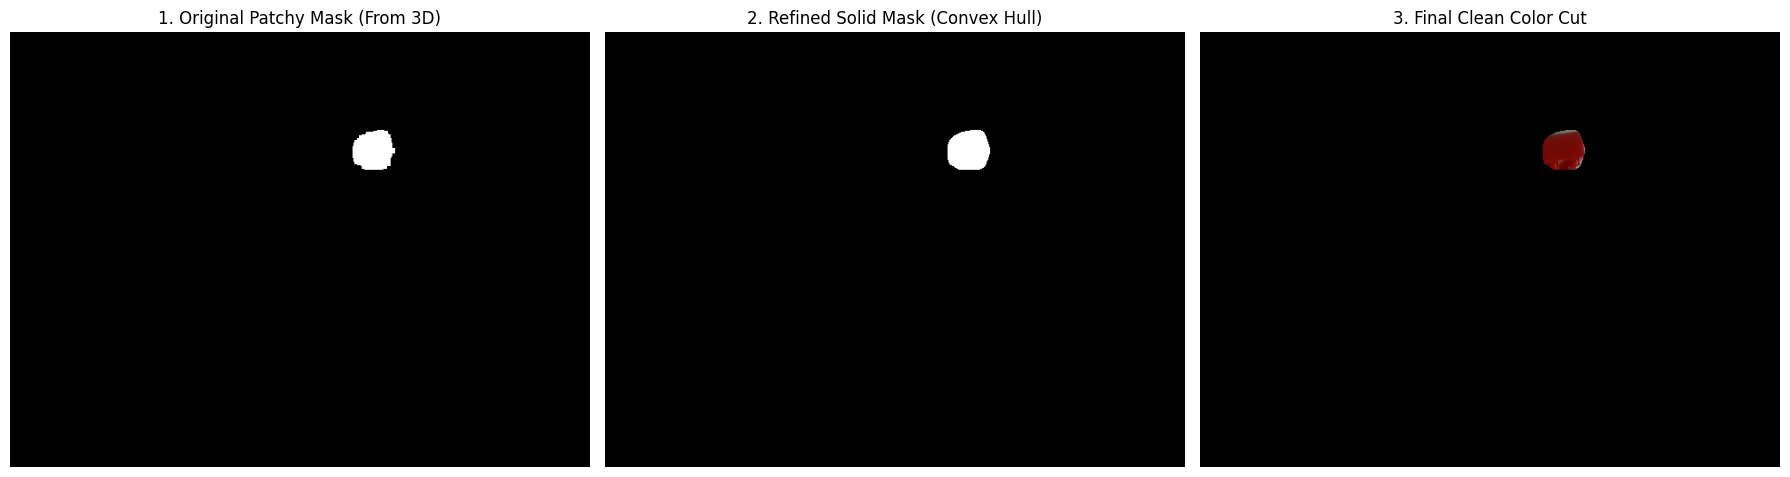


[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...


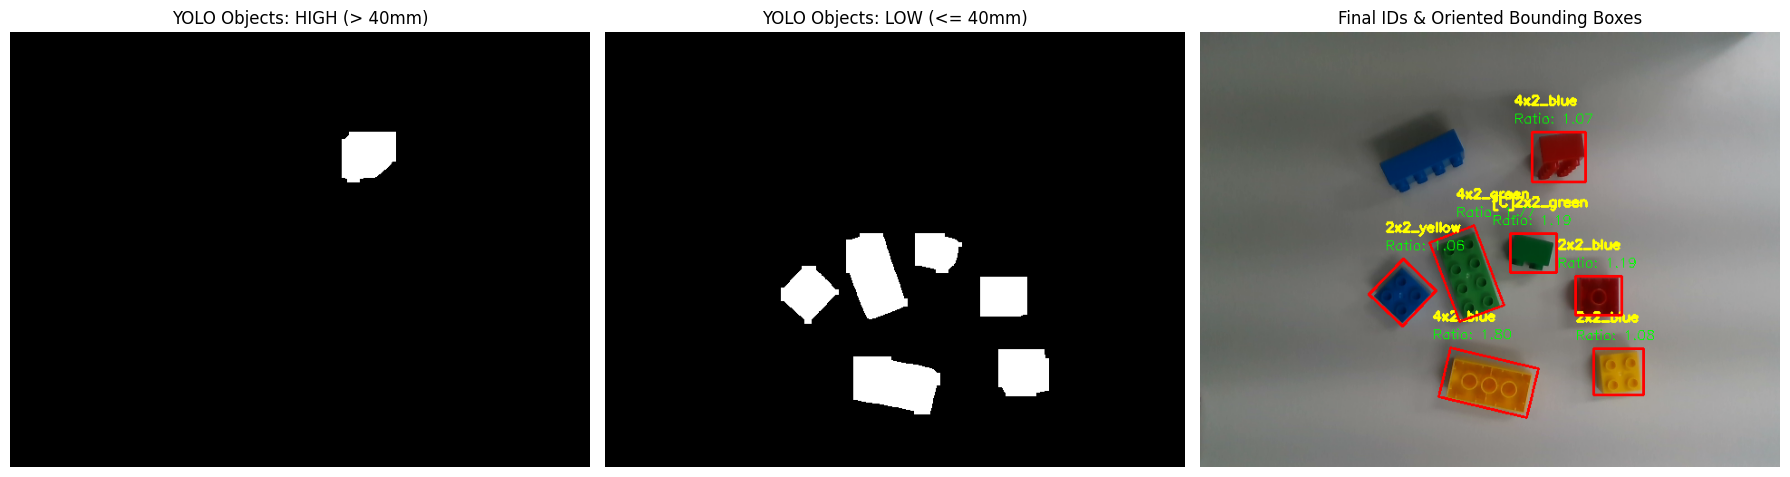

In [66]:
# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects, clean_mask

# =================================================================
# [STEP 1 & 2 통합] DBSCAN+RANSAC 바닥 추정 및 40mm 돌출 맵 사영
# =================================================================
mask_40mm_2d, refined_color, contours, plane_model = ivl.extract_3d_protruding_objects(
    depth_img=depth, 
    color_img_bgr=color_rgb, 
    intrinsics=intrinsics, 
    depth_scale=scale, 
    yolo_combined_mask=clean_mask,
    depth_trunc=3.0,
    height_threshold=0.040,         
    visualize=False  
)

# 3D 마스크 추출에 성공했을 때만 후속 작업 진행
if mask_40mm_2d is not None:
    
    # 💡 [주의] mask_40mm_2d는 현재 0과 255로 이루어져 있습니다. 
    # refine_2d_mask_with_hull 함수는 0과 1 스케일을 예상하므로 변환해서 넘겨줍니다.
    mask_40mm_01 = (mask_40mm_2d > 0).astype(np.uint8)

    # =================================================================
    # [STEP 2.5] Convex Hull을 이용한 조각난 마스크 복원
    # =================================================================
    print("\n[INFO] 조각난 2D 마스크를 Convex Hull을 이용해 복원합니다...")

    refined_mask_01, final_cut_color = ivl.refine_2d_mask_with_hull(
        projected_mask_01=mask_40mm_01, 
        color_bgr=color_rgb
    )
    print("[SUCCESS] 2D 객체 마스크 복원 완료!")

    # 📊 (선택) 복원 결과 시각화
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(mask_40mm_2d, cmap="gray")
    axes[0].set_title("1. Original Patchy Mask (From 3D)")
    axes[0].axis("off")
    axes[1].imshow(refined_mask_01, cmap="gray")
    axes[1].set_title("2. Refined Solid Mask (Convex Hull)")
    axes[1].axis("off")
    axes[2].imshow(cv2.cvtColor(final_cut_color, cv2.COLOR_BGR2RGB))
    axes[2].set_title("3. Final Clean Color Cut")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

    # =================================================================
    # [STEP 3] 최종 OBB 기반 ID 판독 및 교정
    # =================================================================
    # 🎯 핵심: 기존의 mask_40mm_2d 대신, 꽉 채워진 'refined_mask_01'을 넘겨줍니다.
    final_objects, result_vis_img = ivl.correct_object_ids(
        detected_objects=final_objects, 
        mask_high_2d=refined_mask_01, 
        color_img_bgr=color_rgb, 
        ratio_threshold=1.5, 
        overlap_threshold=0.20, 
        visualize=True   
    )
else:
    print("⚠️ 바닥 검출 또는 3D 뎁스 마스크 추출 실패로 인해 파이프라인을 중단합니다.")




# import cv2
# import numpy as np
# import matplotlib.pyplot as plt




# # =================================================================
# # 🎯 [실행 파트] 조각난 마스크 복원
# # =================================================================
# print("[INFO] 조각난 2D 마스크를 Convex Hull을 이용해 복원합니다...")

# refined_mask_01, final_cut_color = ivl.refine_2d_mask_with_hull(
#     projected_mask_01=closed_mask, 
#     color_bgr=color_img_bgr
# )

# print("[SUCCESS] 2D 객체 마스크 복원 완료!")

# # ---------------------------------------------------------
# # 결과 시각화 비교
# # ---------------------------------------------------------
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# axes[0].imshow(closed_mask, cmap="gray")
# axes[0].set_title("1. Original Patchy Mask (From 3D)")
# axes[0].axis("off")

# axes[1].imshow(refined_mask_01, cmap="gray")
# axes[1].set_title("2. Refined Solid Mask (Convex Hull)")
# axes[1].axis("off")

# final_cut_rgb = cv2.cvtColor(final_cut_color, cv2.COLOR_BGR2RGB)
# axes[2].imshow(final_cut_rgb)
# axes[2].set_title("3. Final Clean Color Cut")
# axes[2].axis("off")

# plt.tight_layout()
# plt.show()



[INFO] 3D Scene 분석 및 높이별 2D 마스크 추출 시작...

[INFO] 5mm 객체 영역을 Convex Hull로 복원합니다...

[INFO] YOLO 융합, ID 교정 및 3D 바운딩 박스 생성 중...
 🎯 [높이 강제 고정] 가장 낮은 객체('[C]4x2_blue') 높이: 10.0mm -> 24.0mm


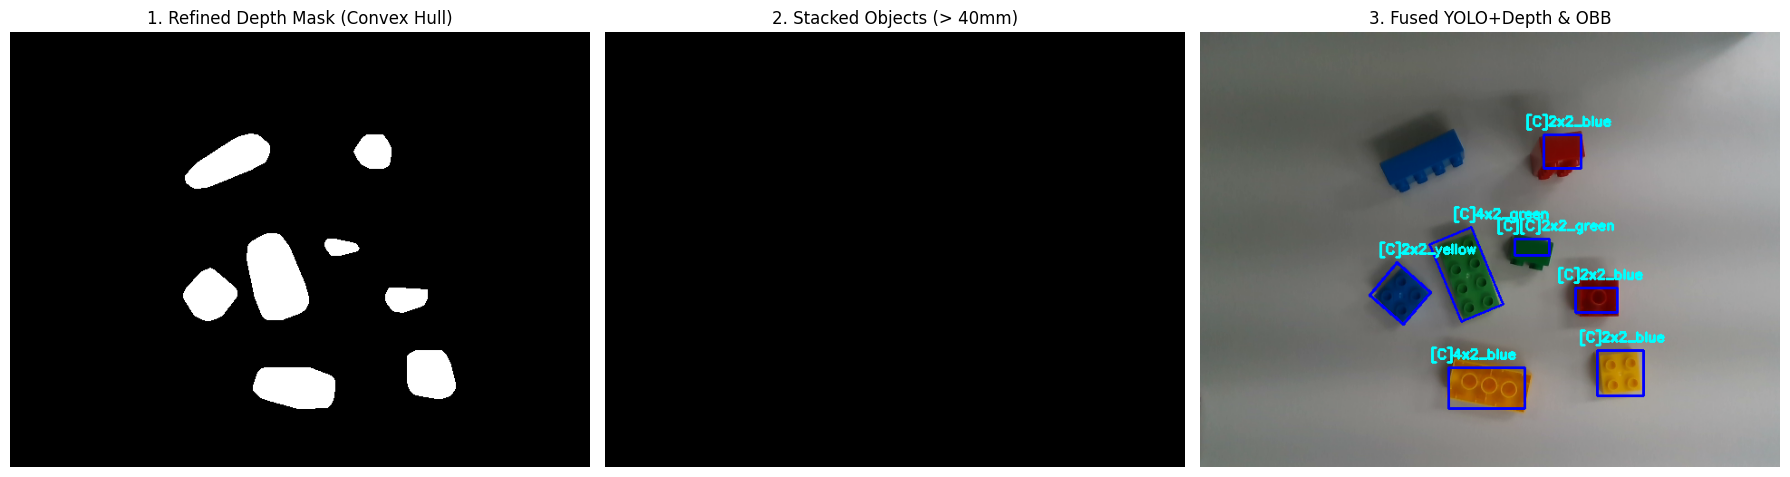


[INFO] 1번 창(분석용 색상 클러스터)을 엽니다. 창을 닫으면 원본 맵이 열립니다.
[INFO] 2번 창(원본 RGB-D 오버레이)을 엽니다.


In [71]:
# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects (YOLO 마스크 정보 포함)

# =================================================================
# [STEP 1] 3D Scene 분석 및 높이별 2D 맵 생성 (5mm, 40mm)
# =================================================================
mask_5mm_2d, mask_40mm_2d, pcd_data, plane_data, floor_pcd = ivl.process_scene_and_get_height_masks(
    depth_img=depth,
    intrinsics=intrinsics,
    depth_scale=scale,
    color_img_shape=color_rgb.shape
)

# =================================================================
# [STEP 2] Convex Hull을 이용한 5mm 객체 마스크 정밀 복원
# =================================================================
print("\n[INFO] 5mm 객체 영역을 Convex Hull로 복원합니다...")
refined_mask_01, _ = ivl.refine_2d_mask_with_hull(
    projected_mask_01=mask_5mm_2d, 
    color_bgr=color_rgb # (참고: 함수 내부에서 cv2.bitwise_and만 하므로 RGB여도 무관)
)

# =================================================================
# [STEP 3] YOLO + 3D 융합, ID 교정 및 3D OBB 생성
# =================================================================
final_objects, vis_3d, overlay_3d, vis_2d, mask_high, mask_low = ivl.fuse_yolo_and_generate_3d_obbs(
    detected_objects=final_objects,
    refined_mask_01=refined_mask_01,
    mask_40mm_2d=mask_40mm_2d,
    pcd_data=pcd_data,
    plane_data=plane_data,
    intrinsics=intrinsics,
    color_img_rgb=color_rgb,
    floor_pcd=floor_pcd
)

# =================================================================
# [STEP 4] 최종 2D/3D 결과 시각화 뷰어 띄우기
# =================================================================
ivl.visualize_final_rgbd_pointcloud(
    color_img_rgb=color_rgb,
    depth_img=depth,
    intrinsics=intrinsics,
    depth_scale=scale,
    refined_mask_01=refined_mask_01,
    mask_high_vis=mask_high,
    vis_image_2d=vis_2d,
    vis_elements_3d=vis_3d,
    overlay_geometries_3d=overlay_3d
)

# 파이프라인 종료 후, 생성된 3D OBB 및 좌표계 정보는 
# 로봇 그리퍼 Target Pose 계산을 위해 활용 가능합니다!






# import cv2
# import numpy as np
# import open3d as o3d
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm



# # =================================================================
# # 1. Depth 전처리 및 3D 점군 생성 (Single Track)
# # =================================================================
# print("\n[STEP 1] Depth 전처리 및 단일 포인트 클라우드 생성...")
# filtered_depth_img = cv2.medianBlur(depth_img, 5)

# o3d_intr = o3d.camera.PinholeCameraIntrinsic(
#     int(intrinsics.width), int(intrinsics.height),
#     float(intrinsics.fx), float(intrinsics.fy),
#     float(intrinsics.ppx), float(intrinsics.ppy)
# )
# o3d_depth_scale = 1.0 / float(depth_scale)

# depth_o3d = o3d.geometry.Image(filtered_depth_img)
# pcd = o3d.geometry.PointCloud.create_from_depth_image(
#     depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=1.5
# )
# pcd = pcd.voxel_down_sample(voxel_size=0.003)
# pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
# pcd, _ = pcd.remove_radius_outlier(nb_points=10, radius=0.01)

# # =================================================================
# # 2. RANSAC 바닥 검출 및 다림질
# # =================================================================
# print("\n[STEP 2] RANSAC 바닥 검출 및 평탄화(다림질)...")
# labels = np.array(pcd.cluster_dbscan(eps=0.02, min_points=20, print_progress=False))
# if len(labels) > 0 and labels.max() >= 0:
#     main_cluster_indices = np.where(labels == np.argmax(np.bincount(labels[labels >= 0])))[0]
#     floor_candidate_pcd = pcd.select_by_index(main_cluster_indices)
#     plane_model, _ = floor_candidate_pcd.segment_plane(distance_threshold=0.015, ransac_n=3, num_iterations=1000)
#     a, b, c, d = plane_model
#     plane_normal = np.array([a, b, c])
#     if c > 0:
#         plane_normal = -plane_normal
#         d = -d

# points = np.asarray(pcd.points)
# signed_height = np.dot(points, plane_normal) + d

# # 바닥 포인트 평탄화
# floor_indices = np.where(signed_height <= 0.005)[0]
# floor_pcd = pcd.select_by_index(floor_indices)
# floor_points = np.asarray(floor_pcd.points)
# distances = np.dot(floor_points, plane_normal) + d
# flattened_points = floor_points - np.outer(distances, plane_normal)
# floor_pcd.points = o3d.utility.Vector3dVector(flattened_points)
# floor_pcd.paint_uniform_color([0.8, 0.8, 0.8])

# # =================================================================
# # 3. 돌출 영역 2D 사영 및 Convex Hull 마스크 복원
# # =================================================================
# print("\n[STEP 3] 돌출 객체 2D 마스크 생성 및 Convex Hull 복원...")
# h, w = color_img_bgr.shape[:2]

# def get_projected_mask(height_threshold):
#     indices = np.where(signed_height > height_threshold)[0]
#     obj_pts = points[indices]
#     mask_2d = np.zeros((h, w), dtype=np.uint8)
#     if len(obj_pts) > 0:
#         x_3d, y_3d = obj_pts[:, 0], obj_pts[:, 1]
#         z_3d = np.where(obj_pts[:, 2] == 0, 0.00001, obj_pts[:, 2])
#         u_coords = np.round((x_3d * intrinsics.fx / z_3d) + intrinsics.ppx).astype(int)
#         v_coords = np.round((y_3d * intrinsics.fy / z_3d) + intrinsics.ppy).astype(int)
#         valid = (u_coords >= 0) & (u_coords < w) & (v_coords >= 0) & (v_coords < h)
#         mask_2d[v_coords[valid], u_coords[valid]] = 1
#     return mask_2d

# # 5mm(마스크 복원용)와 40mm(높이 판별용) 마스크 생성
# mask_5mm_2d = get_projected_mask(0.005)
# mask_40mm_2d = get_projected_mask(0.040)

# # Convex Hull을 이용해 5mm 마스크 정밀 복원
# refined_mask_01, final_cut_color = refine_2d_mask_with_hull(mask_5mm_2d, color_img_bgr)

# # =================================================================
# # 4. YOLO + Depth 융합, ID 교정 및 객체 데이터 수집
# # =================================================================
# print("\n[STEP 4] YOLO 마스크와 3D 데이터 매칭 및 높이 분석 중...")

# vis_image = color_img_bgr.copy()
# N = 1.5
# mask_high_vis = np.zeros((h, w), dtype=np.uint8)
# mask_low_vis = np.zeros((h, w), dtype=np.uint8)

# # 3D -> 2D 픽셀 맵핑 사전 준비
# z_3d_safe = np.where(points[:, 2] == 0, 0.00001, points[:, 2])
# u_all = np.round((points[:, 0] * intrinsics.fx / z_3d_safe) + intrinsics.ppx).astype(int)
# v_all = np.round((points[:, 1] * intrinsics.fy / z_3d_safe) + intrinsics.ppy).astype(int)
# valid_idx = (u_all >= 0) & (u_all < w) & (v_all >= 0) & (v_all < h)
# u_valid, v_valid = u_all[valid_idx], v_all[valid_idx]
# points_valid = points[valid_idx]
# heights_valid = signed_height[valid_idx]

# vis_elements = [floor_pcd] if 'floor_pcd' in locals() else []
# color_dict = {}
# cmap = cm.get_cmap("tab20")

# # 🌟 객체 렌더링 정보를 임시로 담아둘 리스트 생성
# object_data_list = []

# for obj in final_detected_objects:
#     yolo_mask = obj["mask"].astype(np.uint8)
    
#     # YOLO 마스크와 복원된 뎁스 마스크 교집합 적용
#     fused_mask = np.logical_and(yolo_mask > 0, refined_mask_01 > 0).astype(np.uint8)
    
#     contours, _ = cv2.findContours(fused_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     if not contours:
#         continue
        
#     largest_contour = max(contours, key=cv2.contourArea)
#     rect = cv2.minAreaRect(largest_contour)
    
#     rect_w, rect_h = rect[1]
#     ratio = max(rect_w, rect_h) / min(rect_w, rect_h) if min(rect_w, rect_h) > 0 else 0
    
#     overlap_40mm = np.logical_and(fused_mask, mask_40mm_2d)
#     overlap_ratio = np.count_nonzero(overlap_40mm) / np.count_nonzero(fused_mask)
    
#     if "original_name" not in obj:
#         obj["original_name"] = obj["class_name"]
#     old_name = obj["original_name"]
    
#     # [ID 교정 로직]
#     if overlap_ratio > 0.20:
#         mask_high_vis = np.logical_or(mask_high_vis, fused_mask).astype(np.uint8)
#         if "2x2" in old_name:
#             obj["class_name"] = f"[C]{old_name.replace('2x2', '4x2')}"
#         else:
#             obj["class_name"] = f"[C]{old_name}"
#     else:
#         mask_low_vis = np.logical_or(mask_low_vis, fused_mask).astype(np.uint8)
#         if ("4x2" in old_name or "2x4" in old_name) and ratio <= N:
#             obj["class_name"] = f"[C]{old_name.replace('4x2', '2x2').replace('2x4', '2x2')}"
#         else:
#             obj["class_name"] = f"[C]{old_name}"

#     final_id = obj["class_name"]

#     # 3D 객체 포인트 추출 및 최대 높이 계산
#     in_mask_pixels = fused_mask[v_valid, u_valid] > 0
#     obj_heights = heights_valid[in_mask_pixels]
    
#     if len(obj_heights) > 0:
#         max_h = np.percentile(obj_heights, 95)
#         max_h = max(max_h, 0.005) # 최소 5mm 보장
#     else:
#         continue # 3D 포인트가 전혀 없는 오검출 객체는 스킵

#     # 수집된 데이터를 리스트에 저장 (아직 그리지 않음)
#     object_data_list.append({
#         "final_id": final_id,
#         "rect": rect,
#         "in_mask_pixels": in_mask_pixels,
#         "max_h": max_h
#     })

# # =================================================================
# # 5. 최저 높이 객체 판별 및 바닥 밀착형 OBB 렌더링
# # =================================================================
# print("\n[STEP 5] 최저 높이 객체 판별 및 바닥 밀착형 OBB 렌더링 중...")

# # 🌟 원본 컬러 포인트 클라우드에 덮어씌울 박스와 좌표계를 따로 보관할 리스트
# overlay_geometries = []

# if object_data_list:
#     # 🎯 핵심: 수집된 객체들 중 max_h가 가장 작은(가장 낮은) 객체의 인덱스 찾기
#     min_idx = min(range(len(object_data_list)), key=lambda i: object_data_list[i]["max_h"])
#     old_h = object_data_list[min_idx]["max_h"]
    
#     # 가장 낮은 객체의 높이를 24mm (0.024m)로 강제 고정
#     object_data_list[min_idx]["max_h"] = 0.024
#     print(f" 🎯 [높이 강제 고정] 가장 낮은 객체('{object_data_list[min_idx]['final_id']}')의 3D 박스 높이를 {old_h*1000:.1f}mm -> 24.0mm 로 수정했습니다.")

# for data in object_data_list:
#     final_id = data["final_id"]
#     rect = data["rect"]
#     in_mask_pixels = data["in_mask_pixels"]
#     max_h = data["max_h"]

#     if final_id not in color_dict:
#         color_dict[final_id] = cmap(len(color_dict) % 20)[:3]
#     obj_color = color_dict[final_id]

# # 3D 포인트 채색 및 추가
#     obj_pcd = o3d.geometry.PointCloud()
#     obj_pcd.points = o3d.utility.Vector3dVector(points_valid[in_mask_pixels])
#     obj_pcd.paint_uniform_color(obj_color)
#     vis_elements.append(obj_pcd)

#     # 3D OBB 및 좌표계 생성
#     box_2d = cv2.boxPoints(rect)
#     box_2d = np.intp(box_2d)
    
#     box_3d, axes_3d = create_floor_anchored_3d_box_with_axes(
#         box_2d, intrinsics, plane_normal, d, max_h, obj_color, axis_size=0.03
#     )
    
#     # 1. 기존 분석용 시각화 리스트에 추가
#     vis_elements.append(box_3d)
#     vis_elements.append(axes_3d)
    
#     # 2. 🌟 나중에 원본 RGB 맵에 덮어씌우기 위해 따로 보관
#     overlay_geometries.append(box_3d)
#     overlay_geometries.append(axes_3d)
    
#     # 2D 시각화 텍스트/박스 그리기
#     cv2.drawContours(vis_image, [box_2d], 0, (0, 0, 255), 2)
#     top_point = box_2d[np.argmin(box_2d[:, 1])]
#     cv2.putText(vis_image, final_id, (top_point[0] - 20, top_point[1] - 10), 
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

# # =================================================================
# # 6. 시각화 출력 (이후 코드는 동일)
# # =================================================================
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# axes[0].imshow(refined_mask_01, cmap="gray")
# axes[0].set_title("1. Refined Depth Mask (Convex Hull)")
# axes[0].axis("off")

# axes[1].imshow(mask_high_vis, cmap="gray")
# axes[1].set_title("2. Stacked Objects (> 40mm)")
# axes[1].axis("off")

# axes[2].imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
# axes[2].set_title("3. Fused YOLO+Depth & OBB")
# axes[2].axis("off")

# plt.tight_layout()
# plt.show()

# # 🎯 첫 번째 뷰어: 기존 분석용 3D 객체 및 바운딩 박스
# print("\n[INFO] 1번 시각화 창(분석용 색상 클러스터)을 엽니다. 창을 닫으면 원본 맵이 열립니다.")
# o3d.visualization.draw_geometries(vis_elements, window_name="1. Analytical 3D Clustered Objects & OBBs")

# # =================================================================
# # [NEW STEP] 실제 컬러가 입혀진 원본 포인트 클라우드(RGB-D) 생성 및 오버레이
# # =================================================================
# print("\n[STEP 6] 원본 컬러 포인트 클라우드 생성 및 OBB 오버레이 중...")

# # 1. BGR 이미지를 Open3D용 RGB 포맷으로 변환
# color_img_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

# # 2. Open3D Image 객체로 변환
# color_o3d = o3d.geometry.Image(color_img_rgb)
# # Median 필터링된 뎁스를 사용하여 노이즈를 줄인 원본 뎁스 맵 사용
# depth_o3d_raw = o3d.geometry.Image(filtered_depth_img)

# # 3. RGB-D 이미지 생성 (색상과 뎁스 결합)
# rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
#     color_o3d, depth_o3d_raw,
#     depth_scale=o3d_depth_scale,
#     depth_trunc=1.5,
#     convert_rgb_to_intensity=False # 흑백 변환 방지 (컬러 유지)
# )

# # 4. 카메라 파라미터를 이용해 실제 색상이 입혀진 원본 3D 포인트 클라우드 생성
# rgb_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
#     rgbd_image, o3d_intr
# )

# # 시각화 최적화를 위해 살짝 다운샘플링 (1.5mm 간격)
# # 원본 해상도를 그대로 띄우면 뷰어가 너무 무거워질 수 있습니다.
# rgb_pcd = rgb_pcd.voxel_down_sample(voxel_size=0.0015)

# # 5. 원본 포인트 클라우드 리스트에 앞서 따로 보관해둔 바운딩 박스와 좌표계 리스트를 합침
# final_overlay_elements = [rgb_pcd] + overlay_geometries

# # 🎯 두 번째 뷰어: 실제 사진 맵 + 바운딩 박스 오버레이
# print("[INFO] 2번 시각화 창(원본 RGB-D 오버레이)을 엽니다.")
# o3d.visualization.draw_geometries(final_overlay_elements, window_name="2. Real RGB-D Point Cloud with OBBs & Axes")